# ЛАБОРАТОРНАЯ № 1. Детекция автомобилей на видеопотоке со статической камеры методом вычитания фона (Background Subtraction)

**Цель лабораторной:**
1. Изучить классический алгоритм для детекции движущихся объектов.
2. Научиться выделять движущиеся объекты (автомобили) на видеопотоке со статической камеры, используя классический метод вычитания фона. Построить модель фона (опорный кадр) путём усреднения кадров за заданный интервал времени, реализовать полный пайплайн обработки: вычисление абсолютной разности с опорным кадром → пороговая бинаризация → морфологические операции (dilate/erode) → поиск связных компонент → фильтрация по площади → построение bounding box. Провести анализ качества детекции на разных кадрах, замерить производительность алгоритма на CPU и сделать вывод о применимости метода в реальном времени.

**Источники:**
1. Chris Stauffer, W.E.L. Grimson Adaptive Background Mixture Models for Real-Time Tracking https://www.researchgate.net/publication/3813345_Adaptive_Background_Mixture_Models_for_Real-Time_Tracking
2. Python OpenCV - Вычитание фона: https://www.geeksforgeeks.org/python/python-opencv-background-subtraction/

## Импорт библиотек

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Часть 1. Построение модели фона (опорного кадра)

### Загрузка видео

In [3]:
cap = cv2.VideoCapture('./data/raw/raw.mp4')

# сохраняем FPS для сохранения результата в таком же FPS
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

# получаем кадры видео
frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    # OpenCV отдаёт BGR — конвертируем в RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame_rgb)
frames = np.array(frames)

cap.release()

print(f'frames shape: {frames.shape}, type: {frames.dtype}')
print(f'FPS: {fps}')

frames shape: (750, 360, 640, 3), type: uint8
FPS: 25.0


### Создание опорного изображения

In [4]:
background = np.mean(frames, axis=0).astype(np.uint8)

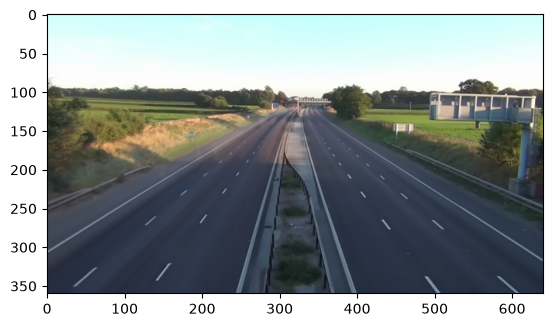

In [5]:
plt.imshow(background)
plt.show()

## Часть 2. Детекция движущихся объектов

### Разность кадров видео с опорным изображением

In [6]:
# типы перевели в int16, что бы разность могла быть отрицательной, чтобы не было переполнения значений
difference = np.abs(frames.astype(np.int16) - background.astype(np.int16))

### Переводим разницу в оттенки серого

In [7]:
# значения по переводу в оттенки серого нашел в интернете
to_gray = np.array([0.2989, 0.5870, 0.114]).reshape(3,1)
difference_gray = (difference @ to_gray).reshape(difference.shape[:-1])

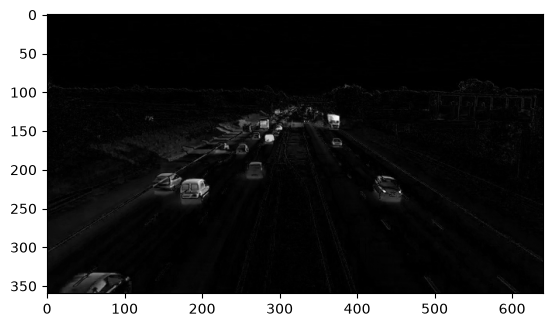

In [8]:
plt.imshow(difference_gray[0], cmap='gray')
plt.show()

### Проводим пороговую бинаризацию

Находим оптимальное значение порога

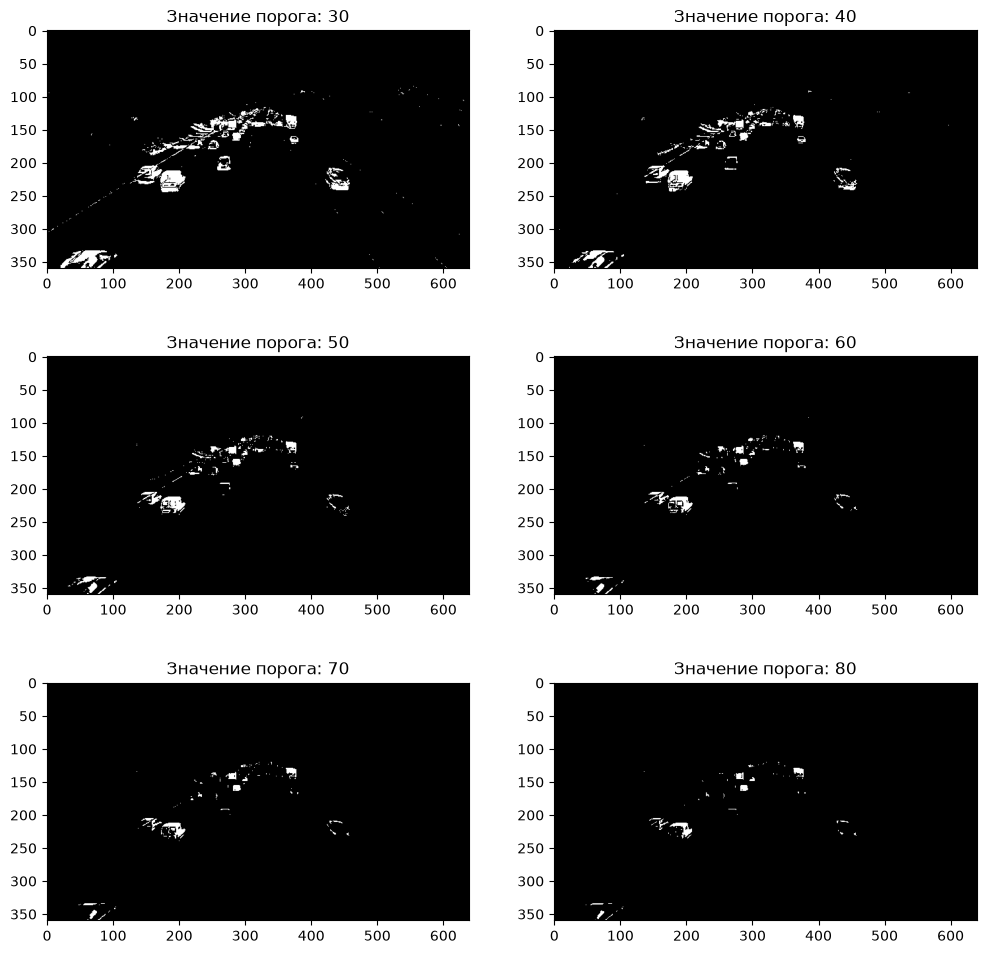

In [9]:
_, axes = plt.subplots(3, 2, figsize=(12, 12))
for ax, limit in zip(axes.ravel(), [30, 40, 50, 60, 70, 80]):
    difference_bin = (difference_gray[0] > limit).astype(np.uint8) * 255

    ax.set_title(f'Значение порога: {limit}')
    ax.imshow(difference_bin, cmap='gray')
plt.show()


В качестве оптимального значения выберем 50

In [10]:
difference_bin = (difference_gray > 50).astype(np.uint8) * 255

### Применяем морфологические операции (dilate -> erode)

Исследуем результаты dilate при разных значениях ядра

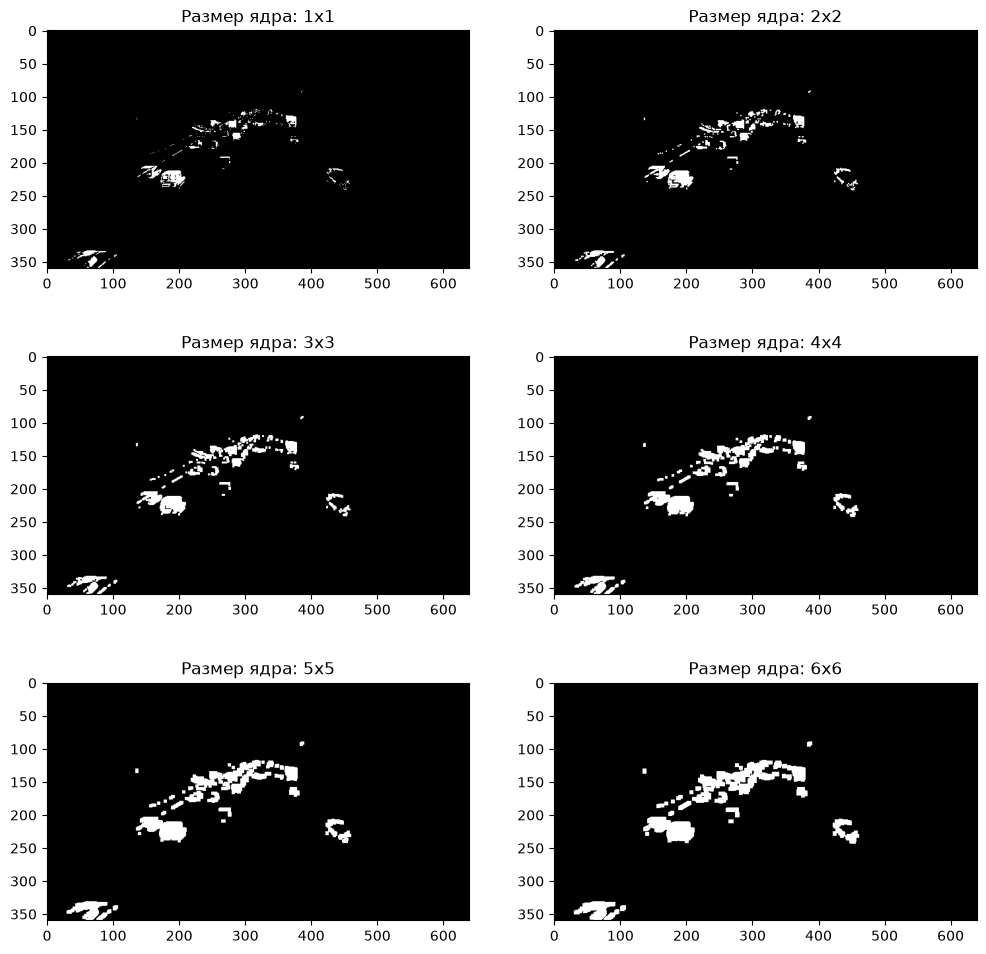

In [11]:
kernel_sizes = [i for i in range(1, 7)]
_, axes = plt.subplots(3, 2, figsize=(12, 12))
for ax, kernel_size in zip(axes.ravel(), kernel_sizes):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    dilated = cv2.dilate(difference_bin[0], kernel)

    ax.set_title(f'Размер ядра: {kernel_size}x{kernel_size}')
    ax.imshow(dilated, cmap='gray')
plt.show()

Оптимальный размер 3x3 так как при больших значениях автомобили начинают сливаться

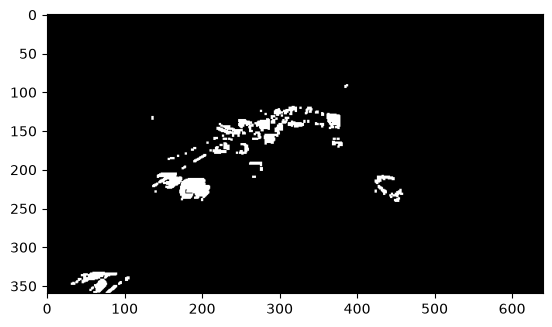

In [12]:
kernel_dilate = np.ones((3, 3), np.uint8)

difference_dilated = np.empty_like(difference_bin)
for i in range(difference_bin.shape[0]):
    difference_dilated[i] = cv2.dilate(difference_bin[i], kernel_dilate)

plt.imshow(difference_dilated[0], cmap='gray')
plt.show()

Исследуем результаты erode при разных значениях ядра

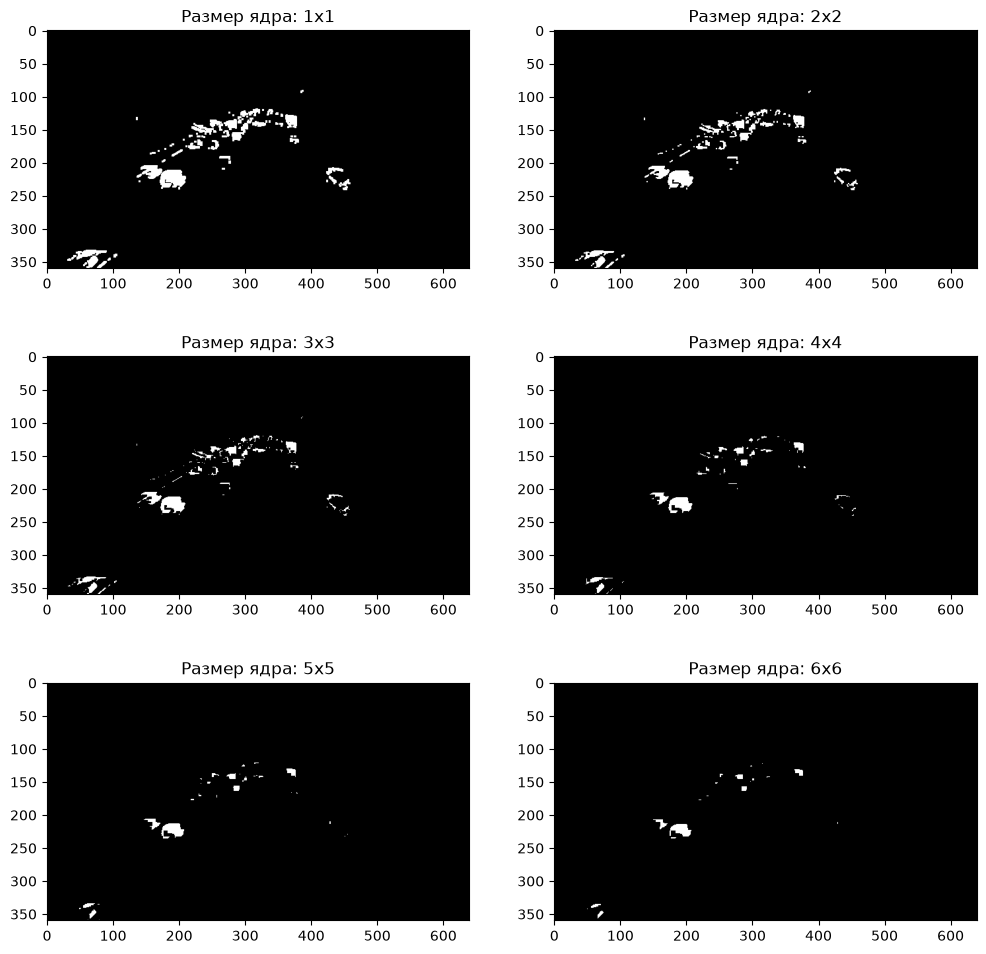

In [13]:
kernel_sizes = [i for i in range(1, 7)]
_, axes = plt.subplots(3, 2, figsize=(12, 12))
for ax, kernel_size in zip(axes.ravel(), kernel_sizes):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    eroded = cv2.erode(difference_dilated[0], kernel)

    ax.set_title(f'Размер ядра: {kernel_size}x{kernel_size}')
    ax.imshow(eroded, cmap='gray')
plt.show()

В качестве оптимального значения выберем 5х5

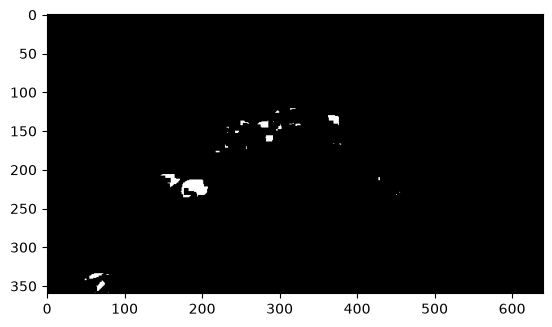

In [14]:
kernel_erode = np.ones((5, 5), np.uint8)

difference_eroded = np.empty_like(difference_dilated)
for i in range(difference_dilated.shape[0]):
    difference_eroded[i] = cv2.erode(difference_dilated[i], kernel_erode)

plt.imshow(difference_eroded[0], cmap='gray')
plt.show()

## Часть 3. Анализ связных компонент и фильтрация шума

### Находим связные компоненты на бинарной маске с использованием 8-связности, получаем статистические характеристики каждой компоненты

In [15]:
num_labels_arr = []
labels_arr = []
stats_arr = []
for i in range(difference_eroded.shape[0]):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        difference_eroded[i], 
        connectivity=8
    )

    num_labels_arr.append(num_labels)
    labels_arr.append(labels)
    stats_arr.append(stats)

num_labels_arr = np.array(num_labels_arr)
labels_arr = np.array(labels_arr)
# stats_arr оставляем списком, так как форма неоднородна

print(f'Колличество компонент на первом кадре: {num_labels_arr[0]}')

Колличество компонент на первом кадре: 31


### Фильтруем компоненты по площади (менее 100 пикселей), строим bounding box для оставшихся компонент, отрисовываем зеленые рамки на исходных кадрах

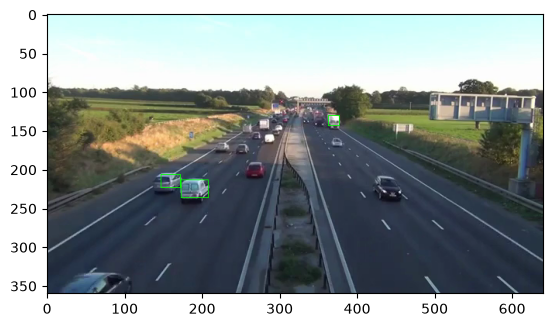

In [16]:
min_area = 100
result_frames = frames.copy()
for i in range(frames.shape[0]):
    num_labels = num_labels_arr[i]
    stats = stats_arr[i]
    for j in range(1, num_labels):
        x, y, w, h, area = stats[j]
        if area < min_area: continue
        cv2.rectangle(result_frames[i], (x, y), (x + w, y + h), (0, 255, 0), 1)

plt.imshow(result_frames[0])
plt.show()

## Часть 4. Запись результата и анализ производительности

### Сохранение результата

In [17]:
H, W = result_frames.shape[1:3]
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('./data/result/result.mp4', fourcc, fps, (W, H))

for frame_rgb in result_frames:
    # RGB -> BGR для OpenCV
    frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    out.write(frame_bgr)

out.release()

## Время обработки каждого кадра после построения фона

Разность кадров с опорным вычислилась 2.0 сек.  
Перевод в оттенки серого всех кадров занял 3.0 сек.  
Бинаризация всех кадров заняла 0.4 сек.  
Dilate и Erode всех кадров заняли по 0.1 сек. (0.2 сек.)  
Анализ связных компонент и фильрация шума всех кадров заняли 1.4 сек.  


Вопрос: как выполнять эти пункты (переписать всю программу с полной проработкой каждого кадра и замерами времени? Как быть с операциями numpy (которые применяются не циклом а ко всему массиву сразу)).  
2. Замерить время обработки каждого кадра после построения фона.  
3. Вывести статистику: среднее, минимальное, максимальное время
обработки кадра, расчётный FPS алгоритма.  
4. Сравнить FPS алгоритма с FPS исходного видео — сделать вывод о
возможности работы в реальном времени.  
5. Проанализировать, какие этапы пайплайна являются наиболее
затратными по времени.  

## Часть 5. Сравнение с методом MOG2.

In [31]:
video_path = './data/raw/raw.mp4'
cap = cv2.VideoCapture(video_path)
fgbg_mog2 = cv2.createBackgroundSubtractorMOG2()
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('./data/result/result_mog2.mp4', fourcc, fps, (W, H))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    fgmask = fgbg_mog2.apply(frame)

    kernel = np.ones((3, 3), np.uint8)
    # fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_OPEN,  kernel)
    fgmask = cv2.dilate(fgmask, kernel)
    fgmask = cv2.erode(fgmask, kernel)
    _, fgmask = cv2.threshold(fgmask, 250, 255, cv2.THRESH_BINARY)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        fgmask,
        connectivity=8
    )

    min_area = 100
    result_frame = frame.copy()
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        if area < min_area: continue
        cv2.rectangle(result_frame, (x, y), (x + w, y + h), (0, 255, 0), 1)
    out.write(result_frame)
cap.release()
out.release()
